# Exploration: XGBoost Features with Simple CNN

Plan for late fusion hybrid:

- **Branch 1: Engineered XGB Features**
- **Branch 2: CNN**
- **Concatenate**

[ CNN vector | tabular vector ] → Dense → prediction

**Input** = Tabular features + MelSpec images based on 6s chunks

**Output** = Category prediction (multiclass) with confidence rating

Notes: 

- Each sample in XGB feature set is a 10 Hz, 6s chunk
- Split by patient to avoid data leakage (test/train and validation) - patient ID in GroupKFold and GroupShuffleSplit
- **Using 5 classes**: COPD, pneumonia, healthy, URTI, bronchiectasis
- **No downsampling of COPD**
- **No audio padding** - both inputs basedon 6s slicing


### Model comparison 👀

| Model              | Approach                                      | Accuracy | Macro F1 | Weighted F1 |
|-------------------|-----------------------------------------------|----------|----------|-------------|
| ⭐ XGBoost         | Tabular engineered features (baseline)        | 0.86     | **0.43** | 0.87        |
| CNN               | Mel spectrogram → CNN                         | 0.66     | 0.22     | 0.72        |
| Hybrid v1         | Early fusion (CNN + XGB → Dense)              | 0.82     | 0.32     | 0.83        |
| Hybrid v2         | CNN embeddings → XGBoost                      | 0.81     | 0.41     | 0.83        |
| Hybrid v3 ⭐       | Late fusion (weighted proba)                  | 0.82     | 0.42     | 0.84        |
| Hybrid v4         | Meta-model (learned fusion)                   | 0.82     | 0.27     | 0.82        |

I explored a few different ways of combining the CNN and XGBoost models to see whether we could improve on the tabular baseline.

The XGBoost model using engineered features remains the strongest overall (macro F1 ~0.43), which suggests those features are already capturing most of the useful signal in the data.

A few observations from the hybrid approaches:

- Early fusion (features → Dense layer) degraded performance (macro F1 ~0.32). The CNN features seem quite noisy at this stage and don’t combine well at feature level.
- CNN embeddings → XGBoost performed better (macro F1 ~0.41), which indicates the CNN is learning some additional signal, but not strongly enough to outperform the baseline.
- Late fusion (weighted probability averaging) was the most effective hybrid approach (macro F1 ~0.42). This also improved recall for some minority classes, suggesting the CNN is contributing useful signal in specific cases.
- Meta-model (learned fusion) performed poorly (macro F1 ~0.27), likely due to overfitting given the limited data.

**Overall takeaway:**

The CNN is picking up some useful patterns, but not consistently enough to beat the XGBoost baseline. 

Late fusion is the most promising way of combining the models, but improving the CNN itself is likely the biggest opportunity if we want to push performance further.


### 📈 Running Summary

#### ⭐️ Tabular XGBoost baseline

Cross-validation summary:

| Fold | Accuracy | Macro F1 | Weighted F1 |
|------|----------|----------|-------------|
| 1    | 0.8125   | 0.4295   | 0.8342      |
| 2    | 0.8732   | 0.3911   | 0.8759      |
| 3    | 0.8852   | 0.4579   | 0.8891      |

Mean metrics:

- accuracy:       0.86
- macro_f1:      0.43
- weighted_f1:    0.87


#### Simple CNN baseline

Mean metrics:

- accuracy:       0.66
- macro_f1:      0.22
- weighted_f1:    0.72


#### Hybrid v1

*CNN and XGBoost create features feeding into a Dense layer*

Mean metrics:

- accuracy:       0.82
- macro_f1:      0.32
- weighted_f1:    0.83


#### Hybrid v2

*Extract CNN features and feed into XGBoost model*

*No scaling - tried but worsened*

Mean metrics:

- accuracy: 0.81
- macro_f1: 0.41
- weighted_f1: 0.83

#### Hybrid v3

*Weighted late fusion hybrid*

*Combines proba from both models*

*Tested range of different weights*

Mean metrics:

- accuracy: 0.82
- macro_f1: 0.42
- weighted_f1: 0.84


#### Hybrid v4

*Meta-model*

*Small model works out how best to combine models' proba values*

Mean metrics:

- accuracy: 0.82
- macro_f1: 0.27
- weighted_f1: 0.82

### Imports

In [1]:
import sys
from pathlib import Path

# Go up one level (from notebooks → project root)
sys.path.append("..")

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import librosa as lb
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

from tensorflow.keras import models, layers, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from smart_stethoscope.ml_logic.preprocessing import preprocess_tabular_data
from smart_stethoscope.ml_logic.audio_preprocessing import build_mel_spectrogram_dataset

## Branch 1: **Engineered XGBoost Features**

### Load XGB data

In [3]:
xgb_df = pd.read_csv("/Users/keira/code/mi-mi-mia/smart-stethoscope/raw_data/Extracted features/xgboost_features_6s_10kHz_compressed.csv")

In [4]:
xgb_df.head()

,rms_mean,zcr_mean,centroid_mean,rolloff_mean,flatness_mean,flux_mean,mfcc_1,mfcc_2,mfcc_3,mfcc_4,...,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,patient_id,chunk_id,original_file,diagnosis
0,0.739170,0.001539,101.449467,127.325543,0.000056,1.957479,141.853965,44.231221,31.555366,29.084454,...,15.377089,13.318531,9.304475,7.877657,7.429528,8.447693,223,0,223_1b1_Pr_sc_Meditron.wav,COPD
1,0.696589,0.001879,98.285502,113.049523,0.000059,1.518246,143.352698,39.783529,33.081844,32.168925,...,15.717680,15.663969,10.037776,7.375149,6.357885,8.668443,223,1,223_1b1_Pr_sc_Meditron.wav,COPD
2,0.670110,0.001899,94.122156,103.863215,0.000033,1.650601,143.955065,47.641450,33.539781,33.385107,...,14.671383,14.495760,10.442390,6.406775,5.649503,9.201296,223,2,223_1b1_Pr_sc_Meditron.wav,COPD
3,0.674821,0.001382,84.610496,86.525093,0.000015,1.759859,140.524004,48.073060,33.807260,31.479628,...,16.430892,14.911375,10.164741,6.695922,5.836122,8.794603,223,3,223_1b1_Pr_sc_Meditron.wav,COPD
4,0.634854,0.001432,85.512759,88.056144,0.000027,1.697848,133.707197,48.023790,28.651836,32.951737,...,18.016766,16.560348,10.037829,6.151356,4.874320,9.356361,223,4,223_1b1_Pr_sc_Meditron.wav,COPD


In [5]:
xgb_df.shape

(2978, 22)

In [6]:
xgb_df.columns

Index(['rms_mean', 'zcr_mean', 'centroid_mean', 'rolloff_mean',
       'flatness_mean', 'flux_mean', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4',
       'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11',
       'mfcc_12', 'patient_id', 'chunk_id', 'original_file', 'diagnosis'],
      dtype='object')

In [7]:
xgb_df.dtypes

rms_mean         float64
zcr_mean         float64
centroid_mean    float64
rolloff_mean     float64
flatness_mean    float64
flux_mean        float64
mfcc_1           float64
mfcc_2           float64
mfcc_3           float64
mfcc_4           float64
mfcc_5           float64
mfcc_6           float64
mfcc_7           float64
mfcc_8           float64
mfcc_9           float64
mfcc_10          float64
mfcc_11          float64
mfcc_12          float64
patient_id         int64
chunk_id           int64
original_file     object
diagnosis         object
dtype: object

In [8]:
xgb_df["diagnosis"].value_counts()

diagnosis
COPD              2597
Pneumonia          111
Healthy            105
URTI                69
Bronchiectasis      48
Bronchiolitis       39
LRTI                 6
Asthma               3
Name: count, dtype: int64

### XGBoost Preprocessing

(to align with Antonella's notebook)

In [9]:
# Filter to same 5 classes - COPD, pneumonia, healthy, URTI, bronchiectasis
classes_to_keep = ["COPD", "Pneumonia", "Healthy", "URTI", "Bronchiectasis"]

xgb_df_filtered = xgb_df[xgb_df["diagnosis"].isin(classes_to_keep)].copy()
xgb_df_filtered = xgb_df_filtered.reset_index(drop=True)

In [10]:
xgb_df_filtered.shape

(2930, 22)

In [11]:
xgb_df_filtered["diagnosis"].value_counts()

diagnosis
COPD              2597
Pneumonia          111
Healthy            105
URTI                69
Bronchiectasis      48
Name: count, dtype: int64

In [12]:
# Encode target
le = LabelEncoder()
xgb_df_filtered["target"] = le.fit_transform(xgb_df_filtered["diagnosis"])

# Create a dictionary mapping labels -> numbers
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

class_mapping

{'Bronchiectasis': 0, 'COPD': 1, 'Healthy': 2, 'Pneumonia': 3, 'URTI': 4}

### XGBoost baseline

In [13]:
# Define features and target
X = xgb_df_filtered.drop(columns=["original_file", "patient_id", "diagnosis", "target", "chunk_id"])
y = xgb_df_filtered["target"]

# Define groups (by patient)
groups = xgb_df_filtered["patient_id"]

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of groups (patients): {groups.nunique()}")
print("\nConfirm feature columns:")
print(list(X.columns))


Feature matrix shape: (2930, 18)
Target shape: (2930,)
Number of groups (patients): 117

Confirm feature columns:
['rms_mean', 'zcr_mean', 'centroid_mean', 'rolloff_mean', 'flatness_mean', 'flux_mean', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12']


In [14]:
# Grouped Cross Validation (split by patient ID)
# Each fold trains on 2/3 of patients, tests on remaining 1/3
gkf = GroupKFold(n_splits=3)

fold_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    print(f"\n{'='*60}")
    print(f"FOLD {fold}")
    print(f"{'='*60}")

    # Outer split: creates grouped train/test splits
    X_train_full = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train_full = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    groups_train_full = groups.iloc[train_idx]

    # Inner split: creates grouped train/validation splits
    gss_val = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
    idx_train, idx_val = next(gss_val.split(X_train_full, y_train_full, groups=groups_train_full))

    X_train = X_train_full.iloc[idx_train]
    X_val = X_train_full.iloc[idx_val]

    y_train = y_train_full.iloc[idx_train]
    y_val = y_train_full.iloc[idx_val]

    # Class-balance sample weights on TRAIN only
    w_train = compute_sample_weight(class_weight="balanced", y=y_train)

    # ==================
    # XGBoost model
    # ==================
    xgb_model = xgb.XGBClassifier(
        n_estimators=500, # number of trees (iterations)
        max_depth=3, # how deep each tree can grow
        objective="multi:softprob", # returns class probabiltities for multiclass
        num_class=len(le.classes_), # matches number of labels
        random_state=42,
        eval_metric="mlogloss", # multiclass log loss, used for earlystopping
        early_stopping_rounds=10 # stop if validation doesn't improve for 10 rounds
    )

    # Train
    xgb_model.fit(
        X_train,
        y_train,
        sample_weight=w_train, # gives more importance to rare classes
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # Predict
    y_pred = xgb_model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"Fold {fold} accuracy   : {acc:.4f}")
    print(f"Fold {fold} macro F1   : {macro_f1:.4f}")
    print(f"Fold {fold} weighted F1: {weighted_f1:.4f}\n")

    print(classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        zero_division=0
    ))

    fold_results.append({
        "fold": fold,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

# =========================================================
# Summary across folds
# =========================================================
results_df = pd.DataFrame(fold_results)

print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY")
print("="*60)
print(results_df)

print("\nMean metrics:")
print(results_df[["accuracy", "macro_f1", "weighted_f1"]].mean())



FOLD 1
Fold 1 accuracy   : 0.8125
Fold 1 macro F1   : 0.4295
Fold 1 weighted F1: 0.8342

                precision    recall  f1-score   support

Bronchiectasis       0.46      0.67      0.55         9
          COPD       0.95      0.87      0.91       862
       Healthy       0.21      0.67      0.32        33
     Pneumonia       0.10      0.14      0.12        36
          URTI       0.35      0.19      0.25        36

      accuracy                           0.81       976
     macro avg       0.42      0.51      0.43       976
  weighted avg       0.87      0.81      0.83       976


FOLD 2
Fold 2 accuracy   : 0.8732
Fold 2 macro F1   : 0.3911
Fold 2 weighted F1: 0.8759

                precision    recall  f1-score   support

Bronchiectasis       0.30      0.20      0.24        15
          COPD       0.96      0.94      0.95       870
       Healthy       0.43      0.56      0.49        36
     Pneumonia       0.23      0.36      0.28        39
          URTI       0.00      0

## Branch 2: **Simple CNN**

### CNN Preprocessing

Defaulting to match XGBoost preprocessing

In [15]:
# Copy existing DF pre-filtered classes (to match XGBoost)
cnn_df = xgb_df_filtered.copy()

cnn_df.shape, cnn_df["diagnosis"].value_counts()

((2930, 23),
 diagnosis
 COPD              2597
 Pneumonia          111
 Healthy            105
 URTI                69
 Bronchiectasis      48
 Name: count, dtype: int64)

In [16]:
# Match XGBoost preprocessing
# - 10 kHz sample rate
# - fixed 6-second slices
TARGET_SR = 10000
CHUNK_DURATION = 6
SAMPLES_PER_CHUNK = TARGET_SR * CHUNK_DURATION

RAW_AUDIO_FOLDER = Path("/Users/keira/code/mi-mi-mia/smart-stethoscope/raw_data/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files")

### Mel Spec feature extraction and test/train splits

In [ ]:
# Load one 6s chunk
def load_one_6s_chunk(original_file, chunk_id):
    # load wav file and resample to 10kHz (matching XGBoost features)
    y, _ = lb.load(RAW_AUDIO_FOLDER / original_file, sr=TARGET_SR)

    # Trim silence to make more consistent chunks
    y, _ = lb.effects.trim(y)

    # Split into consecutive 6s chunks
    chunks = [
        y[i:i + SAMPLES_PER_CHUNK] # take 6 seconds
        for i in range(0, len(y), SAMPLES_PER_CHUNK) # move in 6s steps
        if len(y[i:i + SAMPLES_PER_CHUNK]) == SAMPLES_PER_CHUNK # only keep full chunks
    ]

    return chunks[int(chunk_id)].astype(np.float32)

# Convert chunk into Mel spectogram
def chunk_to_mel(chunk):
    mel = lb.feature.melspectrogram(
        y=chunk,
        sr=TARGET_SR,
        n_mels=128 # number of frequency bands
    )

    # Convert to decibel scale
    mel_db = lb.power_to_db(mel, ref=np.max)

    # Add channel dimension so format work for CNN
    return mel_db[..., np.newaxis].astype(np.float32)

# Build dataset
def build_cnn_dataset(df_subset):
    X_list = [] # stores mel specs
    y_list = [] # stores labels

    # Reconstuct chunk and convert to Mel spec
    # nb 'iteruple' allows looping through df rows
    for row in df_subset.itertuples(index=False):
        chunk = load_one_6s_chunk(row.original_file, row.chunk_id)
        mel = chunk_to_mel(chunk)

        X_list.append(mel)
        y_list.append(row.target)

    return np.stack(X_list), np.array(y_list)

In [18]:
# Grouped split (using same logics as XGBoost)
X_dummy = cnn_df.drop(columns=["diagnosis", "target"])
y = cnn_df["target"]
groups = cnn_df["patient_id"]

gkf = GroupKFold(n_splits=3)
train_idx, test_idx = next(gkf.split(X_dummy, y, groups=groups))

cnn_df_train_full = cnn_df.iloc[train_idx]
cnn_df_test = cnn_df.iloc[test_idx]

gss = GroupShuffleSplit(
    n_splits=1,
    train_size=0.8,
    random_state=42
)

idx_train, idx_val = next(
    gss.split(cnn_df_train_full, cnn_df_train_full["target"], groups=cnn_df_train_full["patient_id"])
)

cnn_df_train = cnn_df_train_full.iloc[idx_train]
cnn_df_val = cnn_df_train_full.iloc[idx_val]

In [19]:
# Build mel datasets

X_train_img, y_train = build_cnn_dataset(cnn_df_train)
X_val_img, y_val = build_cnn_dataset(cnn_df_val)
X_test_img, y_test = build_cnn_dataset(cnn_df_test)

X_train_img.shape

(1544, 128, 118, 1)

In [20]:
# One-hot encode labels
num_classes = len(np.unique(y_train))

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

### Build, train and evaluate the CNN model

CNN architecture:

- Input
- 4 Conv2D blocks
- BatchNorm / ReLU / pooling
- GlobalMaxPooling2D()
- Dense(32)
- Dropout(0.3)
- final Dense(num_classes, softmax output)

In [28]:
def build_cnn(input_shape, num_classes):
    cnn_model = models.Sequential()

    #Input
    cnn_model.add(layers.Input(shape=input_shape))

    # Conv2D Block 1
    cnn_model.add(layers.Conv2D(32, (3, 3), padding="same"))
    cnn_model.add(layers.BatchNormalization())
    cnn_model.add(layers.Activation("relu"))
    cnn_model.add(layers.MaxPooling2D((2, 2)))

    # Conv2D Block 2
    cnn_model.add(layers.Conv2D(64, (3, 3), padding="same"))
    cnn_model.add(layers.BatchNormalization())
    cnn_model.add(layers.Activation("relu"))
    cnn_model.add(layers.MaxPooling2D((2, 2)))

    # Conv2D Block 3
    cnn_model.add(layers.Conv2D(128, (3, 3), padding="same"))
    cnn_model.add(layers.BatchNormalization())
    cnn_model.add(layers.Activation("relu"))
    cnn_model.add(layers.MaxPooling2D((2, 2)))

    # Conv2D Block 4
    cnn_model.add(layers.Conv2D(256, (3, 3), padding="same"))
    cnn_model.add(layers.BatchNormalization())
    cnn_model.add(layers.Activation("relu"))
    cnn_model.add(layers.MaxPooling2D((2, 2)))

    # Turn feature maps into one vector
    cnn_model.add(layers.GlobalMaxPooling2D())

    # Dense layer before classification
    cnn_model.add(layers.Dense(32, activation="relu"))
    cnn_model.add(layers.Dropout(0.3))

    # Final prediction layer
    cnn_model.add(layers.Dense(num_classes, activation="softmax"))

    cnn_model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return cnn_model

cnn_model = build_cnn(X_train_img.shape[1:], num_classes)
cnn_model.summary()

2026-03-23 13:56:11.595024: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-23 13:56:11.595383: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-23 13:56:11.595431: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-03-23 13:56:11.595718: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-23 13:56:11.595747: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 118, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 118, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 118, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 59, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 59, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 59, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 59, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 29, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 398,149 (1.52 MB)

 Trainable params: 397,189 (1.52 MB)

 Non-trainable params: 960 (3.75 KB)

In [24]:
# Class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

In [29]:
# Train
early_stopping = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

cnn_model.fit(
    X_train_img,
    y_train_cat,
    validation_data=(X_val_img, y_val_cat),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/15


2026-03-23 13:56:21.585189: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.3867 - loss: 4.7994 - val_accuracy: 0.0366 - val_loss: 21.5519
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.3802 - loss: 4.4110 - val_accuracy: 0.0366 - val_loss: 13.7642
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.4028 - loss: 3.9318 - val_accuracy: 0.1098 - val_loss: 6.4868
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.4696 - loss: 3.8335 - val_accuracy: 0.3220 - val_loss: 3.2935
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.5395 - loss: 3.5649 - val_accuracy: 0.7610 - val_loss: 0.9348
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.4294 - loss: 3.7565 - val_accuracy: 0.2829 - val_loss: 4.7912
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.4922 - loss: 3.1889 - val_accuracy: 0.4463 - val_loss: 2.1968
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.3122 - loss: 6.3404 - val_accuracy: 0.0805 - val_loss:

In [31]:
# Evaluate
y_pred = np.argmax(cnn_model.predict(X_test_img), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print(classification_report(y_test, y_pred))

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Accuracy: 0.6629098360655737
Macro F1: 0.219454450784745
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.93      0.71      0.81       862
           2       0.05      0.09      0.07        33
           3       0.13      0.83      0.23        36
           4       0.00      0.00      0.00        36

    accuracy                           0.66       976
   macro avg       0.22      0.33      0.22       976
weighted avg       0.83      0.66      0.72       976



/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/keira/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

## Hybrid v1: Concatenate CNN + XGB Features

Above, the CNN ends with:

`Dense(num_classes, softmax)`

For the hybrid model, we'll remove this layer.

The CNN instead should output a feature vector (not predictions).

In [34]:
# BIG PICTURE DESIGN:

# Mel spectrogram
#       ↓
#      CNN
#       ↓
# Feature vector ─────┐
#                     ├─→ Concatenate → Dense → Prediction
# Feature vector ─────┘
#       ↑
#    Dense
#       ↑
# Tabular features

### Align splits across tabular and CNN inputs

In [38]:
# Use SAME indices in tabular as CNN
X_tab_train = X.iloc[train_idx].iloc[idx_train].values
X_tab_val   = X.iloc[train_idx].iloc[idx_val].values
X_tab_test  = X.iloc[test_idx].values

### Rebuild CNN Branch - with feature extractor

In [39]:
def build_cnn_feature_extractor(input_shape):
    inputs = Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalMaxPooling2D()(x)

    # Create CNN feature vector (note: NOT a prediction)
    x = layers.Dense(32, activation="relu")(x)

    return models.Model(inputs, x, name="cnn_branch")

cnn_branch = build_cnn_feature_extractor(X_train_img.shape[1:])

### Define inputs for the hybrid model

In [40]:
# TABULAR BRANCH
# small dense layer to match scale of CNN features
tabular_input = Input(shape=(X_tab_train.shape[1],))
tabular_branch = layers.Dense(32, activation="relu")(tabular_input)

#CNN BRANCH
cnn_input = Input(shape=X_train_img.shape[1:])
cnn_features = cnn_branch(cnn_input)

### Concatenate

In [41]:
combined = layers.concatenate([cnn_features, tabular_branch])

# Create final classifier
x = layers.Dense(64, activation="relu")(combined)
x = layers.Dropout(0.3)(x)
output = layers.Dense(num_classes, activation="softmax")(x)

# Create final model
hybrid_model = models.Model(
    inputs=[cnn_input, tabular_input],
    outputs=output
)

hybrid_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

hybrid_model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 118,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_branch          │ (None, 32)        │    397,984 │ input_layer_5[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │        608 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ cnn_branch[0][0], │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 5)         │        325 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 403,077 (1.54 MB)

 Trainable params: 402,117 (1.53 MB)

 Non-trainable params: 960 (3.75 KB)

### Train and evaluate the hybrid model

In [42]:
early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# Train
history = hybrid_model.fit(
    [X_train_img, X_tab_train],   # BOTH inputs
    y_train_cat,
    validation_data=([X_val_img, X_tab_val], y_val_cat),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.8193 - loss: 22.0485 - val_accuracy: 0.8268 - val_loss: 22.4500
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.8413 - loss: 10.4293 - val_accuracy: 0.8317 - val_loss: 18.8615
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.8439 - loss: 9.5735 - val_accuracy: 0.8122 - val_loss: 15.7922
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.8400 - loss: 8.0842 - val_accuracy: 0.8317 - val_loss: 14.9042
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.8484 - loss: 6.9256 - val_accuracy: 0.8415 - val_loss: 14.1778
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.8627 - loss: 6.3229 - val_accuracy: 0.8439 - val_loss: 14.9551
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.8387 - loss: 7.4646 - val_accuracy: 0.3610 - val_loss: 53.9497
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.8335 - loss: 6.8704 - val_accuracy: 

In [43]:
# Evaluate

test_loss, test_acc = hybrid_model.evaluate(
    [X_test_img, X_tab_test],
    y_test_cat
)

print(f"Test accuracy: {test_acc:.4f}")

# Predictions
y_pred = hybrid_model.predict([X_test_img, X_tab_test])
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=le.classes_,
    zero_division=0
))

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8197 - loss: 5.6422
Test accuracy: 0.8197
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
                precision    recall  f1-score   support

Bronchiectasis       1.00      0.22      0.36         9
          COPD       0.95      0.90      0.92       862
       Healthy       0.16      0.55      0.25        33
     Pneumonia       0.05      0.06      0.05        36
          URTI       0.00      0.00      0.00        36

      accuracy                           0.82       976
     macro avg       0.43      0.35      0.32       976
  weighted avg       0.85      0.82      0.83       976



## Hybrid v2: Extract CNN Features into XGBoost model

Extract features from the trained CNN (NOT predictions).

We take the Dense(32) layer BEFORE the final softmax.

In [46]:
# Use the input tensor from the first layer
cnn_feature_extractor = models.Model(
    inputs=cnn_model.layers[0].input,
    outputs=cnn_model.layers[-3].output  # Dense(32)
)

cnn_feature_extractor.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 118, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 118, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 118, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 118, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 59, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 59, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 59, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 59, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 29, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,984 (1.52 MB)

 Trainable params: 397,024 (1.51 MB)

 Non-trainable params: 960 (3.75 KB)

In [69]:
# Extract CNN features
X_train_cnn_feat = cnn_feature_extractor.predict(X_train_img)
X_val_cnn_feat   = cnn_feature_extractor.predict(X_val_img)
X_test_cnn_feat  = cnn_feature_extractor.predict(X_test_img)

print("Train CNN features:", X_train_cnn_feat.shape)
print("Val CNN features:", X_val_cnn_feat.shape)
print("Test CNN features:", X_test_cnn_feat.shape)

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Train CNN features: (1544, 32)
Val CNN features: (410, 32)
Test CNN features: (976, 32)


In [70]:
# Combine groups to add CNN features
X_train_hybrid = np.concatenate([X_tab_train, X_train_cnn_feat], axis=1)
X_val_hybrid   = np.concatenate([X_tab_val, X_val_cnn_feat], axis=1)
X_test_hybrid  = np.concatenate([X_tab_test, X_test_cnn_feat], axis=1)

In [71]:
# Train the new XGBoost model
xgb_hybrid_feat = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4, # instead of 3 --> may help learn new features
    objective="multi:softprob",
    num_class=len(le.classes_),
    random_state=42,
    eval_metric="mlogloss",
    early_stopping_rounds=10
)

# recompute weights for the new dataset
w_train_hybrid = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

xgb_hybrid_feat.fit(
    X_train_hybrid,
    y_train,
    sample_weight=w_train_hybrid, # includes new weights
    eval_set=[(X_val_hybrid, y_val)],
    verbose=False
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,10
,enable_categorical,False
,eval_metric,'mlogloss'


In [72]:
# Evaluate the model
y_pred = xgb_hybrid_feat.predict(X_test_hybrid)

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    zero_division=0
))

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("\nHybrid (CNN features → XGB):")
print(f"accuracy: {acc:.4f}")
print(f"macro_f1: {macro_f1:.4f}")
print(f"weighted_f1: {weighted_f1:.4f}")


                precision    recall  f1-score   support

Bronchiectasis       0.30      0.67      0.41         9
          COPD       0.95      0.87      0.91       862
       Healthy       0.22      0.64      0.33        33
     Pneumonia       0.19      0.28      0.23        36
          URTI       0.21      0.11      0.15        36

      accuracy                           0.81       976
     macro avg       0.38      0.51      0.41       976
  weighted avg       0.87      0.81      0.83       976


Hybrid (CNN features → XGB):
accuracy: 0.8145
macro_f1: 0.4059
weighted_f1: 0.8345


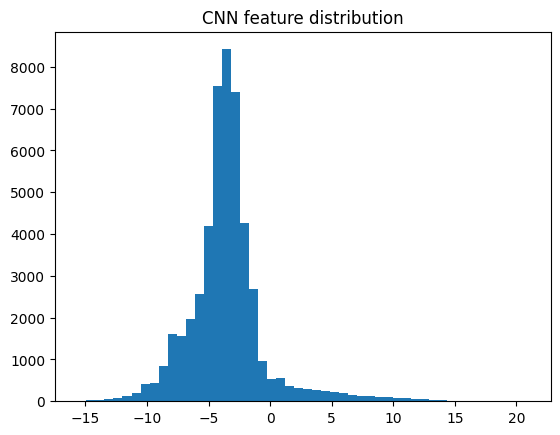

In [59]:
import matplotlib.pyplot as plt

plt.hist(X_train_cnn_feat.flatten(), bins=50)
plt.title("CNN feature distribution")
plt.show()

## Hybrid v3: Late fusion XGB and CNN

Combine class probabilities from both models

In [73]:
# Train a new XGBoost model on the same split as the CNN

# Recompute sample weights for this train split
# Important: weights must match the current y_train length exactly
w_train_late = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# Create a fresh XGBoost model for late fusion
# We keep this separate so we don't overwrite previous models/results
xgb_late = xgb.XGBClassifier(
    n_estimators=500,              # number of trees
    max_depth=4,                   # using the slightly deeper version that helped earlier
    objective="multi:softprob",    # returns probabilities for each class
    num_class=len(le.classes_),    # number of classes
    random_state=42,
    eval_metric="mlogloss",        # validation metric for early stopping
    early_stopping_rounds=10
)

# Train on tabular features only
xgb_late.fit(
    X_tab_train,
    y_train,
    sample_weight=w_train_late,
    eval_set=[(X_tab_val, y_val)],
    verbose=False
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,10
,enable_categorical,False
,eval_metric,'mlogloss'


In [74]:
# GET PROBABILITIES FROM BOTH MODELS

# XGBoost probabilities
# Shape: (n_samples, num_classes)
xgb_val_probs = xgb_late.predict_proba(X_tab_val)
xgb_test_probs = xgb_late.predict_proba(X_tab_test)

# CNN probabilities
# cnn_model already outputs softmax probabilities
cnn_val_probs = cnn_model.predict(X_val_img)
cnn_test_probs = cnn_model.predict(X_test_img)

# Quick sanity check
print("xgb_val_probs shape:", xgb_val_probs.shape)
print("cnn_val_probs shape:", cnn_val_probs.shape)
print("xgb_test_probs shape:", xgb_test_probs.shape)
print("cnn_test_probs shape:", cnn_test_probs.shape)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
xgb_val_probs shape: (410, 5)
cnn_val_probs shape: (410, 5)
xgb_test_probs shape: (976, 5)
cnn_test_probs shape: (976, 5)


#### Option A: Weighted average of probabilities

In [75]:
# Start with XGBoost getting more influence because it is the stronger model
xgb_weight = 0.8
cnn_weight = 0.2

# Combine probabilities class-by-class
val_probs_weighted = (xgb_weight * xgb_val_probs) + (cnn_weight * cnn_val_probs)
test_probs_weighted = (xgb_weight * xgb_test_probs) + (cnn_weight * cnn_test_probs)

# Convert probabilities to class predictions
y_val_pred_weighted = np.argmax(val_probs_weighted, axis=1)
y_test_pred_weighted = np.argmax(test_probs_weighted, axis=1)

# Evaluate on validation set first
print("Validation results - weighted average")
print(classification_report(
    y_val,
    y_val_pred_weighted,
    target_names=le.classes_,
    zero_division=0
))

val_acc = accuracy_score(y_val, y_val_pred_weighted)
val_macro_f1 = f1_score(y_val, y_val_pred_weighted, average="macro")
val_weighted_f1 = f1_score(y_val, y_val_pred_weighted, average="weighted")

print(f"val accuracy: {val_acc:.4f}")
print(f"val macro_f1: {val_macro_f1:.4f}")
print(f"val weighted_f1: {val_weighted_f1:.4f}")

# Evaluate on test set
print("\nTest results - weighted average")
print(classification_report(
    y_test,
    y_test_pred_weighted,
    target_names=le.classes_,
    zero_division=0
))

test_acc = accuracy_score(y_test, y_test_pred_weighted)
test_macro_f1 = f1_score(y_test, y_test_pred_weighted, average="macro")
test_weighted_f1 = f1_score(y_test, y_test_pred_weighted, average="weighted")

print(f"test accuracy: {test_acc:.4f}")
print(f"test macro_f1: {test_macro_f1:.4f}")
print(f"test weighted_f1: {test_weighted_f1:.4f}")

Validation results - weighted average
                precision    recall  f1-score   support

Bronchiectasis       0.00      0.00      0.00         6
          COPD       0.91      0.99      0.95       341
       Healthy       0.57      0.53      0.55        15
     Pneumonia       0.75      0.38      0.51        39
          URTI       0.00      0.00      0.00         9

      accuracy                           0.88       410
     macro avg       0.45      0.38      0.40       410
  weighted avg       0.85      0.88      0.86       410

val accuracy: 0.8805
val macro_f1: 0.4014
val weighted_f1: 0.8560

Test results - weighted average
                precision    recall  f1-score   support

Bronchiectasis       0.32      0.67      0.43         9
          COPD       0.95      0.88      0.91       862
       Healthy       0.26      0.58      0.36        33
     Pneumonia       0.15      0.25      0.19        36
          URTI       0.30      0.17      0.21        36

      accuracy    

In [76]:
# Weighting Sweep!
# Try a few simple weightings and keep the best validation macro F1

weight_results = []

for xgb_weight in [0.9, 0.8, 0.7, 0.6]:
    cnn_weight = 1 - xgb_weight

    # Weighted average of probabilities
    val_probs = (xgb_weight * xgb_val_probs) + (cnn_weight * cnn_val_probs)
    val_preds = np.argmax(val_probs, axis=1)

    # Metrics on validation set
    val_acc = accuracy_score(y_val, val_preds)
    val_macro_f1 = f1_score(y_val, val_preds, average="macro")
    val_weighted_f1 = f1_score(y_val, val_preds, average="weighted")

    weight_results.append({
        "xgb_weight": xgb_weight,
        "cnn_weight": cnn_weight,
        "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1,
        "val_weighted_f1": val_weighted_f1
    })

# Show results
weight_results_df = pd.DataFrame(weight_results)
print(weight_results_df.sort_values("val_macro_f1", ascending=False))

   xgb_weight  cnn_weight  val_accuracy  val_macro_f1  val_weighted_f1
2         0.7         0.3      0.887805      0.412672         0.864233
3         0.6         0.4      0.887805      0.412672         0.864233
1         0.8         0.2      0.880488      0.401395         0.855995
0         0.9         0.1      0.873171      0.384623         0.845100


#### Option B: Meta-model --> Let a model figure out how to combine models

Instead of manually choosing weights, we let a tiny neural net learn how to combine the two models’ probability outputs.

Important: To keep leakage lower in this quick version, we train the meta-model on validation predictions, then evaluate on test predictions. That is not perfect stacking, but it is a decent bootcamp-speed version.

In [78]:
# Concatenate XGB probs + CNN probs
# =========================

# Each row becomes:
# [p(class1 from XGB), ..., p(class5 from XGB), p(class1 from CNN), ..., p(class5 from CNN)]
X_meta_val = np.concatenate([xgb_val_probs, cnn_val_probs], axis=1)
X_meta_test = np.concatenate([xgb_test_probs, cnn_test_probs], axis=1)

print("X_meta_val shape:", X_meta_val.shape)
print("X_meta_test shape:", X_meta_test.shape)

X_meta_val shape: (410, 10)
X_meta_test shape: (976, 10)


In [79]:
# TINY META-MODEL
# Learns how to combine the two models' probability outputs
# =========================

meta_model = models.Sequential()

# Input size = num_classes from XGB + num_classes from CNN
meta_model.add(layers.Input(shape=(X_meta_val.shape[1],)))

# Small hidden layer
meta_model.add(layers.Dense(16, activation="relu"))

# Final multiclass output
meta_model.add(layers.Dense(num_classes, activation="softmax"))

meta_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

meta_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
# Train meta-model
# We train on validation predictions because the base models were tuned before
# =========================

# Convert y_val / y_test to categorical if needed
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

history = meta_model.fit(
    X_meta_val,                 # validation-set combined predictions as input
    y_val_cat,                  # validation labels
    epochs=30,
    batch_size=16,
    verbose=1
)

# Evaluate on test
test_loss, test_acc = meta_model.evaluate(X_meta_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# Final predictions
y_test_meta_probs = meta_model.predict(X_meta_test)
y_test_meta_pred = np.argmax(y_test_meta_probs, axis=1)

print(classification_report(
    y_test,
    y_test_meta_pred,
    target_names=le.classes_,
    zero_division=0
))

test_macro_f1 = f1_score(y_test, y_test_meta_pred, average="macro")
test_weighted_f1 = f1_score(y_test, y_test_meta_pred, average="weighted")

print("\nLate fusion (meta-model):")
print(f"accuracy: {test_acc:.4f}")
print(f"macro_f1: {test_macro_f1:.4f}")
print(f"weighted_f1: {test_weighted_f1:.4f}")

Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0073 - loss: 2.0024 
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0122 - loss: 1.6956
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5049 - loss: 1.4210
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8317 - loss: 1.1787
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8317 - loss: 0.9731
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8317 - loss: 0.8177
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8317 - loss: 0.7127
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8317 - loss: 0.6458
Epoch 9/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8317 - loss: 0.6027
Epoch 10/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8317 - loss: 0.5736
Epoch 11/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8317 - loss: 0.5516
Epoch 12/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8317 -